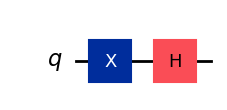

<IPython.core.display.Latex object>

In [2]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
from qiskit.quantum_info import Statevector

#One qubit states
qc_1 = QuantumCircuit(1)
qc_1.x(0) # NOT gate
qc_1.h(0) # Hadamard gate


display(qc_1.draw('mpl'))
state = Statevector.from_instruction(qc_1)
display(state.draw(output='latex'))

In [2]:
#Two qubit states
qc_2 = QuantumCircuit(2)
qc_2.h(0)
qc_2.h(1)

state = Statevector.from_instruction(qc_2)
display(state.draw(output='latex'))

<IPython.core.display.Latex object>

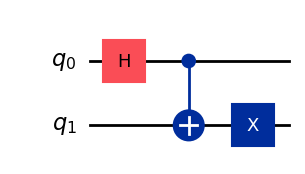

<IPython.core.display.Latex object>

In [3]:
#Bell states
qc_3 = QuantumCircuit(2)
# qc_3.x(0)

qc_3.h(0)
qc_3.cx(0, 1) #The first one is the control qubit, the second one is the target quibit
qc_3.x(1)

display(qc_3.draw('mpl'))
state = Statevector.from_instruction(qc_3)
display(state.draw(output='latex'))

In [4]:
#Three qubit states

qc_4 = QuantumCircuit(3)
qc_4.h(0)
qc_4.h(1)
qc_4.h(2)

state = Statevector.from_instruction(qc_4)
display(state.draw(output='latex'))

<IPython.core.display.Latex object>

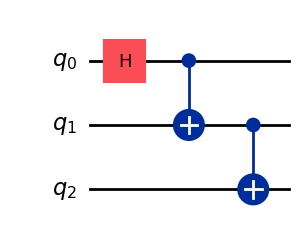

<IPython.core.display.Latex object>

In [5]:
#Three qubit GHZ state
qc_5= QuantumCircuit(3)
qc_5.h(0)
qc_5.cx(0, 1)
qc_5.cx(1, 2)

display(qc_5.draw('mpl'))
state = Statevector.from_instruction(qc_5)
display(state.draw(output='latex'))

Now it's time to play with histograms etc


Measured: 111
Post-measurement state:


<IPython.core.display.Latex object>

{np.str_('000'): np.int64(511), np.str_('111'): np.int64(513)}

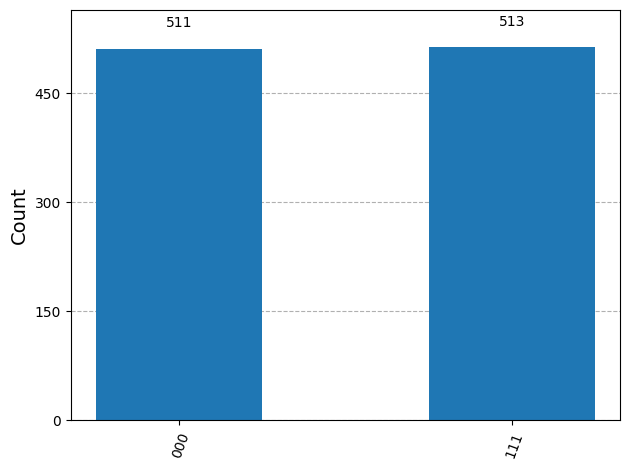

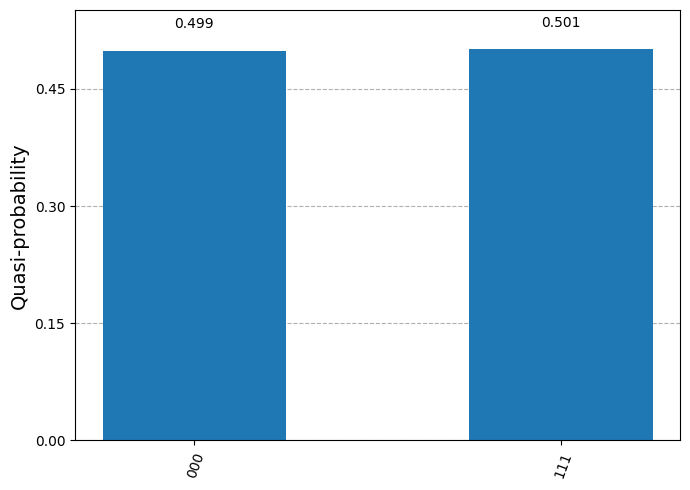

In [6]:
from qiskit.visualization import plot_histogram, plot_distribution

outcome, v = state.measure()               # single measurement
print(f"Measured: {outcome}\nPost-measurement state:")
display(v.draw("latex"))


n_shots=1024 # specify numbert of shots.   # number of shots
statistics = state.sample_counts(n_shots)  # staticstics over n_shots measurements
display(statistics)                        
display(plot_histogram(statistics))        # plot histogram with number of measurements of avaliable states
display(plot_distribution(statistics))     # plot histogram with probabilites of avaliable states

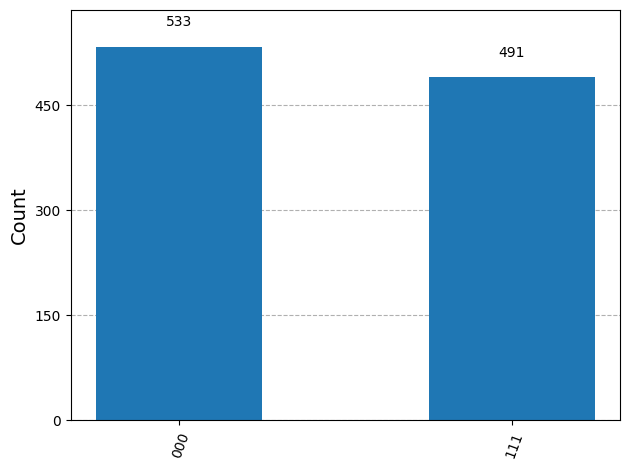

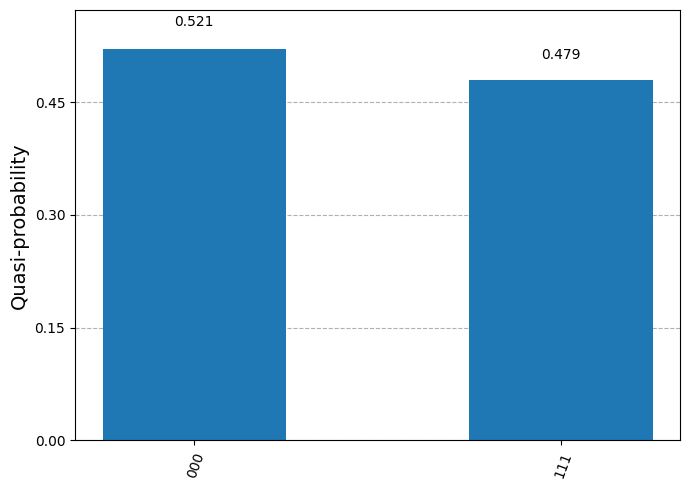

In [7]:
from qiskit.primitives import StatevectorSampler

#there has to be a measurement at the end of the qc circuit
qc_5.measure_all()
sampler = StatevectorSampler()
result = sampler.run([qc_5], shots=1024).result()
data_pub = result[0].data
counts = data_pub.meas.get_counts()
display(plot_histogram(counts), plot_distribution(counts))

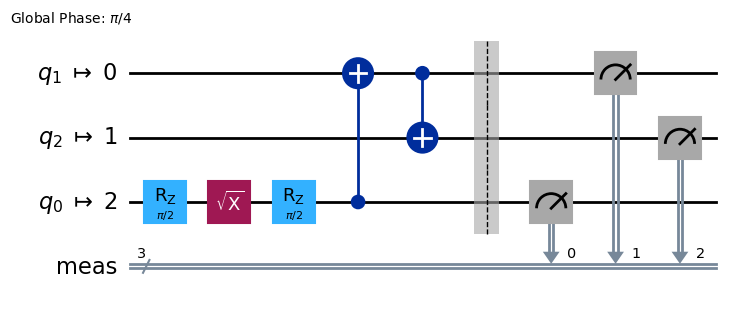

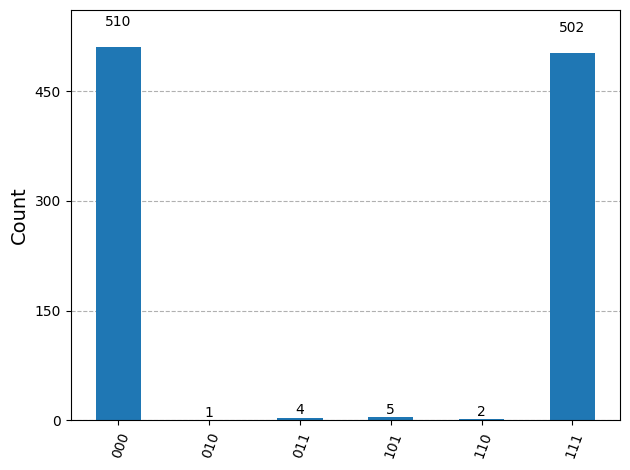

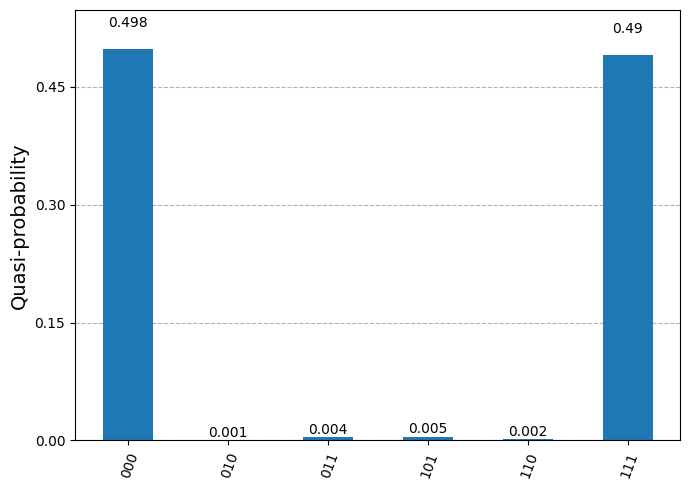

In [8]:
# Generate a nq-qubit simulated backend
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.providers.fake_provider import GenericBackendV2
nq=3
backend = GenericBackendV2(num_qubits=nq)

# Transpile the ideal circuit to a circuit that can be directly executed by the backend
transpiled_circuit = transpile(qc_5, backend)
display(transpiled_circuit.draw('mpl'))

# Run the transpiled circuit using the simulated backend
job = backend.run(transpiled_circuit)
counts_r = job.result().get_counts()
display(plot_histogram(counts_r))
display(plot_distribution(counts_r))

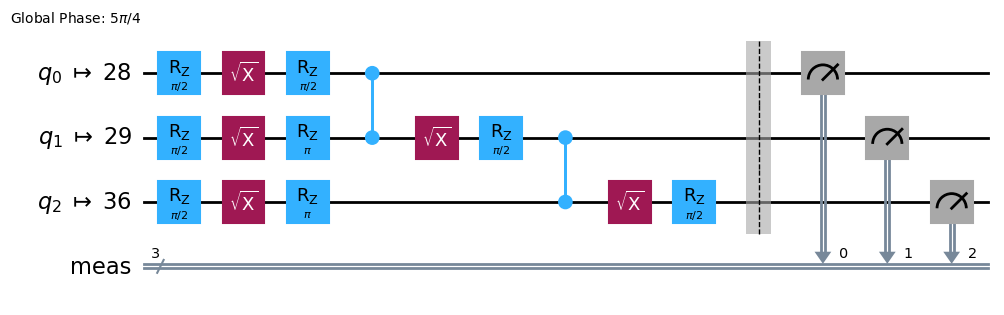

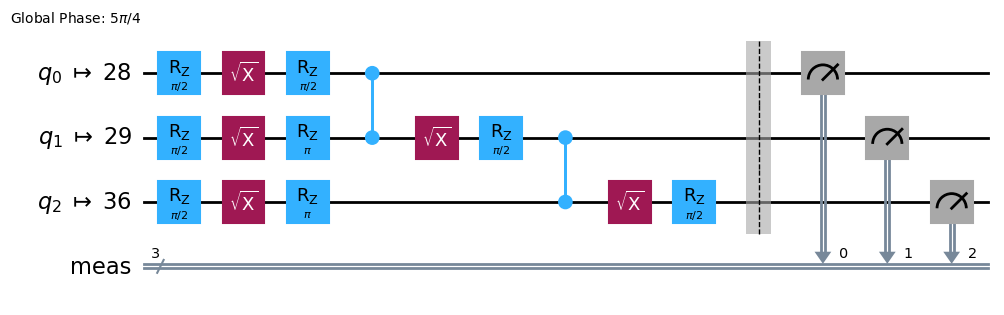

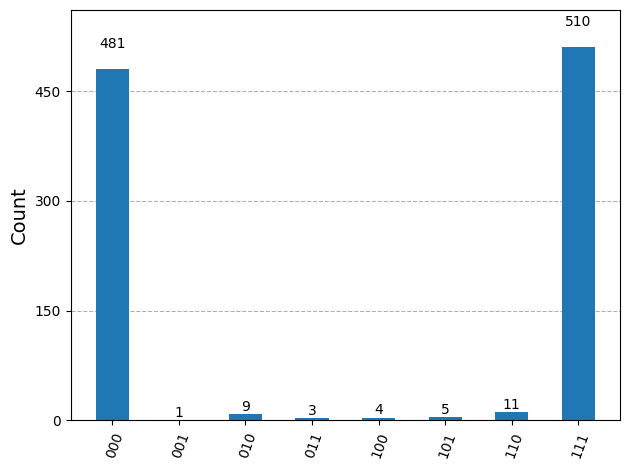

In [10]:
# e) Run the quantum circuit (including noise) using selected ```fake_provider``` (mimicking one of the existing quantum processors, e.g. FakeTorino) from fake provider module (https://quantum.cloud.ibm.com/docs/en/api/qiskit-ibm-runtime/fake-provider) for a backend. <br>
# Example for ```qc``` circuit:
# ```


from qiskit_ibm_runtime.fake_provider import FakeSherbrooke, FakeKyiv, FakeTorino
from qiskit_ibm_runtime import SamplerV2


backend_FT=FakeTorino()
backend_FT.description

# Transpile the ideal circuit to a circuit that can be directly executed by the backend
transpiled_circuit = transpile(qc_5, backend_FT)
display(transpiled_circuit.draw('mpl'))

# Run the transpiled circuit using the simulated backend
job = backend_FT.run(transpiled_circuit)
counts = job.result().get_counts()
plot_histogram(counts)
# ```

# Example for ```qc``` circuit using ```SamplerV2``` primitive:

# ```
backend_FT=FakeTorino()
backend_FT.description

# Transpile the ideal circuit to a circuit that can be directly executed by the backend
transpiled_circuit = transpile(qc_5, backend_FT)
display(transpiled_circuit.draw('mpl'))

# Run the transpiled circuit using the simulated fake backend
sampler = SamplerV2(backend_FT)
job = sampler.run([transpiled_circuit])
pub_result = job.result()[0]
counts = pub_result.data.meas.get_counts()
plot_histogram(counts)
